In [1]:
import numpy as np
np.random.seed(42)

sentence = ["Bank", "of", "the", "river"]
seq_len = len(sentence)
d_model = 8

print(f"sentence: {sentence}")
print(f"seq_len = {seq_len}, d_model = {d_model}")

sentence: ['Bank', 'of', 'the', 'river']
seq_len = 4, d_model = 8


In [3]:
def build_embeddings(vocab_words, d_model, seed=0):
    # Toy embedding table: one random vector per unique word.
    # Shape returned: (len(vocab_words), d_model)
    rng = np.random.default_rng(seed)
    print(f"rng: {rng}")
    print()
    vocab = sorted(set(vocab_words))
    print(f"vocab: {vocab}")
    print()
    table = {w: rng.normal(size=d_model) for w in vocab}
    print(f"table: {table}")
    print()
    return table

vocab_words = ["bank", "of", "the", "river", "account", "money", "has", "today"]
embedding_table = build_embeddings(vocab_words, d_model, seed=0)

X = np.stack([embedding_table[w.lower()] for w in sentence])  # (seq_len, d_model)
print("X shape (seq_len, d_model):", X.shape)
for w, vec in zip(sentence, X):
    print(f"  x_{w:<6} shape={vec.shape}  first 3 dims={np.round(vec[:3], 2)}")

rng: Generator(PCG64)

vocab: ['account', 'bank', 'has', 'money', 'of', 'river', 'the', 'today']

table: {'account': array([ 0.12573022, -0.13210486,  0.64042265,  0.10490012, -0.53566937,
        0.36159505,  1.30400005,  0.94708096]), 'bank': array([-0.70373524, -1.26542147, -0.62327446,  0.04132598, -2.32503077,
       -0.21879166, -1.24591095, -0.73226735]), 'has': array([-0.54425898, -0.31630016,  0.41163054,  1.04251337, -0.12853466,
        1.36646347, -0.66519467,  0.35151007]), 'money': array([ 0.90347018,  0.0940123 , -0.74349925, -0.92172538, -0.45772583,
        0.22019512, -1.00961818, -0.20917557]), 'of': array([-0.15922501,  0.54084558,  0.21465912,  0.35537271, -0.65382861,
       -0.12961363,  0.78397547,  1.49343115]), 'river': array([-1.25906553,  1.51392377,  1.34587542,  0.7813114 ,  0.26445563,
       -0.31392281,  1.45802068,  1.96025832]), 'the': array([ 1.80163487,  1.31510376,  0.35738041, -1.20831863, -0.00445413,
        0.65647494, -1.28836146,  0.39512206]

In [4]:
d_k = d_model 

rng = np.random.default_rng(1)
W_q = rng.normal(scale=0.5, size=(d_model, d_k))
W_k = rng.normal(scale=0.5, size=(d_model, d_k))
W_v = rng.normal(scale=0.5, size=(d_model, d_k))

Q = X @ W_q   # (seq_len, d_k)
K = X @ W_k   # (seq_len, d_k)
V = X @ W_v   # (seq_len, d_k)

print("X:", X.shape, " W_q:", W_q.shape, " -> Q:", Q.shape)
print("K:", K.shape, "  V:", V.shape)


X: (4, 8)  W_q: (8, 8)  -> Q: (4, 8)
K: (4, 8)   V: (4, 8)


In [5]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

scores = Q @ K.T / np.sqrt(d_k)          # (seq_len, seq_len)
attn_weights = softmax(scores, axis=-1)  # (seq_len, seq_len), rows sum to 1

print("scores shape:", scores.shape, " (seq_len, seq_len)")
print("attention weights (rows = query word, cols = key word):\n")
header = "        " + "".join(f"{w:>8}" for w in sentence)
print(header)
for w, row in zip(sentence, attn_weights):
    print(f"{w:>8}" + "".join(f"{v:8.3f}" for v in row))
print("\nrow sums (should all be 1.0):", np.round(attn_weights.sum(axis=1), 6))

scores shape: (4, 4)  (seq_len, seq_len)
attention weights (rows = query word, cols = key word):

            Bank      of     the   river
    Bank   0.215   0.251   0.388   0.145
      of   0.074   0.255   0.161   0.509
     the   0.004   0.129   0.029   0.838
   river   0.071   0.223   0.450   0.256

row sums (should all be 1.0): [1. 1. 1. 1.]


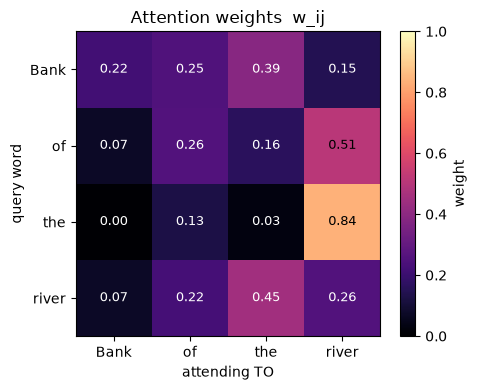

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attn_weights, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(seq_len)); ax.set_xticklabels(sentence)
ax.set_yticks(range(seq_len)); ax.set_yticklabels(sentence)
ax.set_xlabel("attending TO"); ax.set_ylabel("query word")
ax.set_title("Attention weights  w_ij")
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f"{attn_weights[i,j]:.2f}", ha="center", va="center",
                 color="white" if attn_weights[i,j] < 0.5 else "black", fontsize=9)
fig.colorbar(im, ax=ax, label="weight")
plt.tight_layout()
plt.show()

In [7]:
Y = attn_weights @ V   # (seq_len, d_k)  <-- this is y1, y2, y3, y4 stacked

print("Y shape (seq_len, d_k):", Y.shape)
for w, y_i, weights in zip(sentence, Y, attn_weights):
    contributors = ", ".join(f"w({w}->{sw})={wt:.2f}" for sw, wt in zip(sentence, weights))
    print(f"y_{w:<6} shape={y_i.shape}   {contributors}")

Y shape (seq_len, d_k): (4, 8)
y_Bank   shape=(8,)   w(Bank->Bank)=0.22, w(Bank->of)=0.25, w(Bank->the)=0.39, w(Bank->river)=0.15
y_of     shape=(8,)   w(of->Bank)=0.07, w(of->of)=0.26, w(of->the)=0.16, w(of->river)=0.51
y_the    shape=(8,)   w(the->Bank)=0.00, w(the->of)=0.13, w(the->the)=0.03, w(the->river)=0.84
y_river  shape=(8,)   w(river->Bank)=0.07, w(river->of)=0.22, w(river->the)=0.45, w(river->river)=0.26


In [8]:
Y_literal = attn_weights @ X   # exactly y_i = sum_j w_ij * x_j, matching the image

y1_manual = (attn_weights[0,0]*X[0] + attn_weights[0,1]*X[1]
             + attn_weights[0,2]*X[2] + attn_weights[0,3]*X[3])

print("y1 via matrix form   (first 3 dims):", np.round(Y_literal[0][:3], 4))
print("y1 via manual formula(first 3 dims):", np.round(y1_manual[:3], 4))
print("identical:", np.allclose(Y_literal[0], y1_manual))

y1 via matrix form   (first 3 dims): [0.3247 0.5943 0.2543]
y1 via manual formula(first 3 dims): [0.3247 0.5943 0.2543]
identical: True


In [9]:
def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

x_bank, x_river = X[0], X[3]
y_bank = Y[0]

print(f"cosine(x_bank, x_river) = {cosine(x_bank, x_river):.4f}   <- static embedding, no context")
print(f"cosine(y_bank, x_river) = {cosine(y_bank, x_river):.4f}   <- after attention, pulled toward context")
print()
print("attention weight bank->river:", f"{attn_weights[0,3]:.3f}",
      "(highest weight bank gives to any word other than itself)"
      if attn_weights[0,3] == attn_weights[0,1:].max() else "")
    

cosine(x_bank, x_river) = -0.5045   <- static embedding, no context
cosine(y_bank, x_river) = -0.6063   <- after attention, pulled toward context

attention weight bank->river: 0.145 


In [10]:
def attention(sentence_words, embedding_table, W_q, W_k, W_v):
    X = np.stack([embedding_table[w.lower()] for w in sentence_words])
    Q, K, V = X @ W_q, X @ W_k, X @ W_v
    scores = Q @ K.T / np.sqrt(W_q.shape[1])
    weights = softmax(scores, axis=-1)
    Y = weights @ V
    return X, Y, weights

sentence_river  = ["bank", "of", "the", "river"]
sentence_money  = ["bank", "account", "has", "money"]

X_river, Y_river, W_river = attention(sentence_river, embedding_table, W_q, W_k, W_v)
X_money, Y_money, W_money = attention(sentence_money, embedding_table, W_q, W_k, W_v)

x_bank_river, x_bank_money = X_river[0], X_money[0]
y_bank_river, y_bank_money = Y_river[0], Y_money[0]

print("Raw embeddings x_bank identical across sentences?",
      np.allclose(x_bank_river, x_bank_money), " (they must be - same lookup table)")
print("cosine(x_bank_river, x_bank_money) =", round(cosine(x_bank_river, x_bank_money), 6))
print()
print("Contextualized y_bank identical across sentences?",
      np.allclose(y_bank_river, y_bank_money))
print("cosine(y_bank_river, y_bank_money) =", round(cosine(y_bank_river, y_bank_money), 4),
      " <- meaningfully less than 1: same word, different meaning-vector")

Raw embeddings x_bank identical across sentences? True  (they must be - same lookup table)
cosine(x_bank_river, x_bank_money) = 1.0

Contextualized y_bank identical across sentences? False
cosine(y_bank_river, y_bank_money) = 0.3625  <- meaningfully less than 1: same word, different meaning-vector


In [11]:
x_river_vec  = embedding_table["river"]
x_money_vec  = embedding_table["money"]
x_account_vec = embedding_table["account"]

print("In the RIVER sentence:")
print(f"  cosine(y_bank, x_river)   = {cosine(y_bank_river, x_river_vec):.4f}")
print(f"  cosine(y_bank, x_money)   = {cosine(y_bank_river, x_money_vec):.4f}")
print()
print("In the MONEY sentence:")
print(f"  cosine(y_bank, x_river)   = {cosine(y_bank_money, x_river_vec):.4f}")
print(f"  cosine(y_bank, x_money)   = {cosine(y_bank_money, x_money_vec):.4f}")
print(f"  cosine(y_bank, x_account) = {cosine(y_bank_money, x_account_vec):.4f}")

In the RIVER sentence:
  cosine(y_bank, x_river)   = -0.6063
  cosine(y_bank, x_money)   = 0.6502

In the MONEY sentence:
  cosine(y_bank, x_river)   = -0.2282
  cosine(y_bank, x_money)   = 0.3902
  cosine(y_bank, x_account) = -0.6801


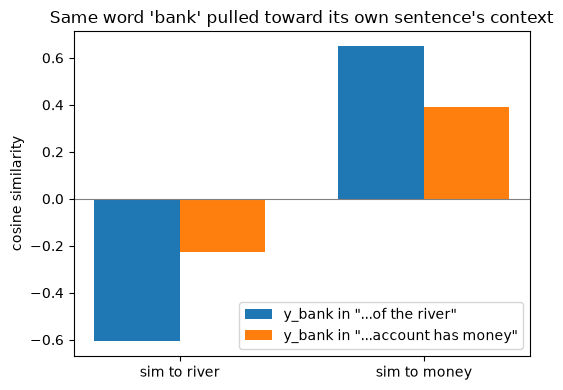

In [12]:
import matplotlib.pyplot as plt

labels = ["sim to river", "sim to money"]
river_sentence_sims = [cosine(y_bank_river, x_river_vec), cosine(y_bank_river, x_money_vec)]
money_sentence_sims = [cosine(y_bank_money, x_river_vec), cosine(y_bank_money, x_money_vec)]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(x - width/2, river_sentence_sims, width, label='y_bank in "...of the river"')
ax.bar(x + width/2, money_sentence_sims, width, label='y_bank in "...account has money"')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("cosine similarity")
ax.set_title("Same word 'bank' pulled toward its own sentence's context")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

## Pytorch Impementation

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

vocab = ["bank", "of", "the", "river", "account", "money", "has", "today"]
idx = torch.tensor([word2idx[w] for w in sentence]) 

d_model = 8
embedding = nn.Embedding(num_embeddings=len(vocab), embedding_dim=d_model)

sentence = ["bank", "of", "the", "river"]

idx = torch.tensor([word2idx[w] for w in sentence]) 
X = embedding(idx)

print("X shape:", X.shape)

X shape: torch.Size([4, 8])


In [26]:
d_k = d_model 

W_q = nn.Linear(d_model, d_k, bias=False)
W_k = nn.Linear(d_model, d_k, bias=False)
W_v = nn.Linear(d_model, d_k, bias=False)

Q = W_q(X)
K = W_k(X)
V = W_v(X)

scores = Q @ K.T / (d_k ** 0.5)
attn_weights = F.softmax(scores, dim=-1)
Y = attn_weights @ V
print("Q,K,V shapes:", tuple(Q.shape), tuple(K.shape), tuple(V.shape))
print("attn_weights shape:", tuple(attn_weights.shape))
print("Y shape (contextualized outputs):", tuple(Y.shape))
print(attn_weights)

Q,K,V shapes: (4, 8) (4, 8) (4, 8)
attn_weights shape: (4, 4)
Y shape (contextualized outputs): (4, 8)
tensor([[0.2669, 0.2226, 0.3062, 0.2044],
        [0.2706, 0.2266, 0.2599, 0.2429],
        [0.1957, 0.2539, 0.3324, 0.2180],
        [0.2714, 0.2123, 0.3017, 0.2146]], grad_fn=<SoftmaxBackward0>)


In [27]:
mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=1, bias=False, batch_first=True)

X_batched = X.unsqueeze(0)
Y_mha, attn_weights_mha = mha(X_batched, X_batched, X_batched)
print("input shape:", tuple(X_batched.shape))          # (1, 4, 8)
print("output Y shape:", tuple(Y_mha.shape))            # (1, 4, 8)
print("attn weights shape:", tuple(attn_weights_mha.shape))  # (1, 4, 4)

input shape: (1, 4, 8)
output Y shape: (1, 4, 8)
attn weights shape: (1, 4, 4)


In [28]:
def run_attention(words, embedding, W_q, W_k, W_v):
    idx = torch.tensor([word2idx[w] for w in words])
    X = embedding(idx)
    Q, K, V = W_q(X), W_k(X), W_v(X)
    scores = Q @ K.T / (X.shape[-1] ** 0.5)
    weights = F.softmax(scores, dim=-1)
    Y = weights @ V
    return X, Y, weights

X_river, Y_river, _ = run_attention(["bank", "of", "the", "river"], embedding, W_q, W_k, W_v)
X_money, Y_money, _ = run_attention(["bank", "account", "has", "money"], embedding, W_q, W_k, W_v)

cos = nn.CosineSimilarity(dim=0)
print("x_bank identical across sentences:", torch.allclose(X_river[0], X_money[0]))
print("cosine(y_bank_river, y_bank_money):", cos(Y_river[0], Y_money[0]).item())

x_bank identical across sentences: True
cosine(y_bank_river, y_bank_money): -0.06932274997234344


## Using Glove

In [29]:
import gensim.downloader as api
wv = api.load("glove-wiki-gigaword-50") 

[==================================================] 100.0% 66.0/66.0MB downloaded


In [30]:
wv["bank"]        # → a NumPy vector, shape (50,)

array([ 0.66488 , -0.11391 ,  0.67844 ,  0.17951 ,  0.6828  , -0.47787 ,
       -0.30761 ,  0.17489 , -0.70512 , -0.55022 ,  0.1514  ,  0.10214 ,
       -0.45063 , -0.33069 ,  0.056133,  1.2271  ,  0.55607 , -0.68297 ,
        0.037364,  0.70266 ,  1.9093  , -0.61483 , -0.83329 , -0.3023  ,
       -1.1118  , -1.55    ,  0.2604  ,  0.22957 , -1.0375  , -0.31789 ,
        3.5091  , -0.25871 ,  1.0151  ,  0.65927 , -0.18231 , -0.75859 ,
       -0.30927 , -0.91678 ,  1.0633  , -0.66761 , -0.37464 , -0.29143 ,
        0.65606 , -0.44642 , -0.075495, -1.0552  , -0.60501 ,  0.73582 ,
        1.0139  , -0.27749 ], dtype=float32)

In [38]:
sentence = ["bank", "of", "the", "river"]

X = torch.tensor([wv[w] for w in sentence]) 

In [45]:
X.shape[-1]

50

In [48]:
W_q = nn.Linear(X.shape[-1], X.shape[-1], bias=False)
W_k = nn.Linear(X.shape[-1], X.shape[-1], bias=False)
W_v = nn.Linear(X.shape[-1], X.shape[-1], bias=False)

Q = W_q(X)
K = W_k(X)
V = W_v(X)

scores = Q @ K.T / (X.shape[-1] ** 0.5)
attn_weights = F.softmax(scores, dim=-1)
Y = attn_weights @ V
print("Q,K,V shapes:", tuple(Q.shape), tuple(K.shape), tuple(V.shape))
print("attn_weights shape:", tuple(attn_weights.shape))
print("Y shape (contextualized outputs):", tuple(Y.shape))
print(attn_weights)

Q,K,V shapes: (4, 50) (4, 50) (4, 50)
attn_weights shape: (4, 4)
Y shape (contextualized outputs): (4, 50)
tensor([[0.2625, 0.2688, 0.2487, 0.2201],
        [0.2148, 0.2638, 0.2557, 0.2657],
        [0.2355, 0.2723, 0.2692, 0.2230],
        [0.1917, 0.2552, 0.2315, 0.3216]], grad_fn=<SoftmaxBackward0>)


In [53]:
def run_attention(words, wv, W_q, W_k, W_v):
    X = torch.tensor([wv[w] for w in words]) 
    Q, K, V = W_q(X), W_k(X), W_v(X)
    scores = Q @ K.T / (X.shape[-1] ** 0.5)
    weights = F.softmax(scores, dim=-1)
    Y = weights @ V
    return X, Y, weights

X_river, Y_river, _ = run_attention(["bank", "of", "the", "river"], wv, W_q, W_k, W_v)
X_money, Y_money, _ = run_attention(["bank", "account", "has", "money"], wv, W_q, W_k, W_v)

cos = nn.CosineSimilarity(dim=0)
print("x_bank identical across sentences:", torch.allclose(X_river[0], X_money[0]))
print("cosine(y_bank_river, y_bank_money):", cos(Y_river[0], Y_money[0]).item())

x_bank identical across sentences: True
cosine(y_bank_river, y_bank_money): 0.8811593055725098
